In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [139]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score , mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures 

In [13]:
df = pd.read_csv("C:/Users/himan/Downloads/kc_house_data_NaN.csv")
df.head(3)

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [15]:
df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [49]:
df.drop('id' , axis = 1)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [53]:
df.drop(df.columns[[0]] , axis = 1)
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [60]:
floor_df = df['floors'].value_counts().to_frame()
floor_df

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


In [124]:
num_df = df.select_dtypes(include = ['number'])
num_df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
price,1.000000,0.308794,0.525905,0.701909,0.089882,0.256814,0.266437,0.397318,0.036025,0.667922,0.605371,0.323776,0.053984,0.126415,-0.053437,0.306777,0.022092,0.585247,0.082837
bedrooms,0.308794,1.000000,0.514508,0.578212,0.032471,0.177944,-0.006834,0.080008,0.026496,0.356563,0.479386,0.302808,0.155670,0.018389,-0.154092,-0.009951,0.132054,0.393406,0.030690
bathrooms,0.525905,0.514508,1.000000,0.755758,0.088373,0.502582,0.063744,0.188386,-0.126479,0.665838,0.686668,0.283440,0.507173,0.050544,-0.204786,0.024280,0.224903,0.569884,0.088303
sqft_living,0.701909,0.578212,0.755758,1.000000,0.173453,0.353953,0.103854,0.284709,-0.059445,0.762779,0.876448,0.435130,0.318152,0.055308,-0.199802,0.052155,0.241214,0.756402,0.184342
sqft_lot,0.089882,0.032471,0.088373,0.173453,1.000000,-0.004814,0.021632,0.074900,-0.008830,0.114731,0.184139,0.015418,0.052946,0.007686,-0.129586,-0.085514,0.230227,0.144763,0.718204
floors,0.256814,0.177944,0.502582,0.353953,-0.004814,1.000000,0.023755,0.028814,-0.264075,0.458794,0.523989,-0.245715,0.489193,0.006427,-0.059541,0.049239,0.125943,0.280102,-0.010722
waterfront,0.266437,-0.006834,0.063744,0.103854,0.021632,0.023755,1.000000,0.401971,0.016611,0.082888,0.072109,0.080559,-0.026153,0.092873,0.030272,-0.014306,-0.041904,0.086507,0.030781
view,0.397318,0.080008,0.188386,0.284709,0.074900,0.028814,0.401971,1.000000,0.045999,0.251728,0.167609,0.277078,-0.053636,0.103951,0.084622,0.005871,-0.078107,0.280681,0.072904
condition,0.036025,0.026496,-0.126479,-0.059445,-0.008830,-0.264075,0.016611,0.045999,1.000000,-0.146896,-0.158904,0.173849,-0.361592,-0.060788,0.002888,-0.015102,-0.105877,-0.093072,-0.003126
grade,0.667922,0.356563,0.665838,0.762779,0.114731,0.458794,0.082888,0.251728,-0.146896,1.000000,0.756073,0.168220,0.447865,0.014261,-0.185771,0.113575,0.200341,0.713867,0.120981


<Axes: xlabel='waterfront', ylabel='price'>

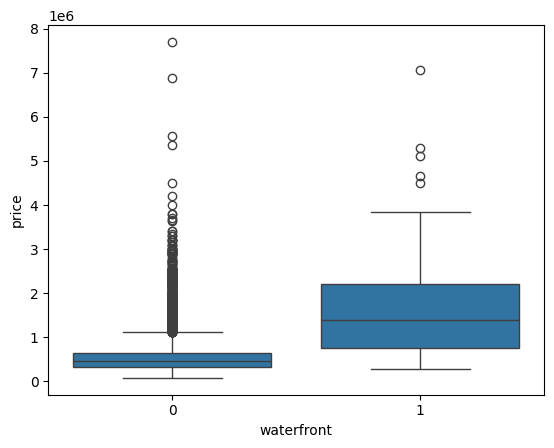

In [61]:
sns.boxplot(x = 'waterfront' , y = 'price' , data = df)

<Axes: xlabel='sqft_above', ylabel='price'>

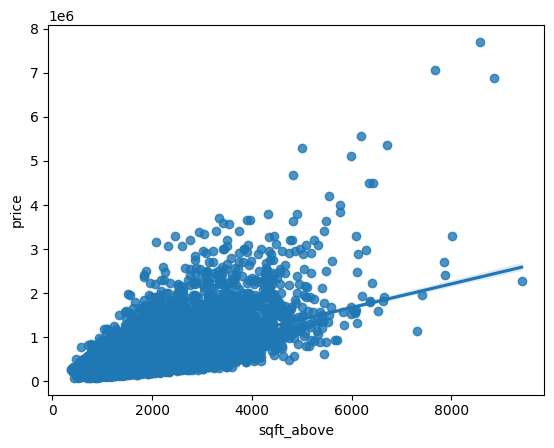

In [147]:
sns.regplot(x = 'sqft_above' , y = 'price' , data = df)

In [69]:
lr = LinearRegression()
x = df[['sqft_living']]
y = df['price']
display(lr.fit(x , y))
print(lr.score(x, y))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


0.4928532179037931


In [ ]:
df.dropna(subset = ['bedrooms'] , axis = 0 , inplace = True)
df['bedrooms'].value_counts(dropna = False)

In [ ]:
df.dropna(subset = ['bathrooms'] , axis = 0 , inplace = True)
df['bathrooms'].value_counts(dropna = False)

In [143]:
multi_lin = LinearRegression()
Z = df[['bedrooms' , 'bathrooms']]
S = df['price']
display(multi_lin.fit(Z,S))
print(multi_lin.coef_ , multi_lin.intercept_)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


[ 20597.54951299 238315.55736489] -33511.051217207336


In [110]:
x_train , x_test , y_train, y_test = train_test_split(x, y, test_size=0.10, random_state=1)
print(x_train.shape[0] , y_test.shape[0])
R_cross = cross_val_score(lr , x_train[['sqft_living']], y_train, cv = 4) #cv represents folds 
print(R_cross)
R_cross_test = cross_val_score(lr , x_test[['sqft_living']] , y_test, cv = 4)
print(R_cross_test)

19451 2162
[0.50740682 0.47889661 0.48311436 0.49962718]
[0.45519668 0.46502751 0.48051376 0.50983428]


In [130]:
ridgem = Ridge()
#lr.ridge(alpha = 0.1)
ridgem.fit(x_train, y_train)
yhat = ridgem.predict(x_test)
print(r2_score(y_test, yhat))

0.48489043226077566


        5         4             3             2
-13.27 x + 887.2 x - 1.912e+04 x + 1.526e+05 x - 3.549e+05 x + 6.162e+05


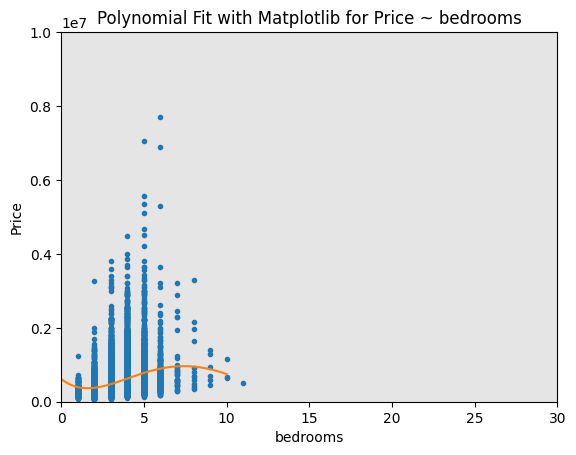

In [197]:
def PlotPoly(model, independent_variable, dependent_variabble, Name):
    x_new = np.linspace(0, 10, 100)
    #y_new = df['price']
    y_new = model(x_new)

    
    plt.plot(independent_variable, dependent_variabble, '.', x_new, y_new, '-')
    plt.title('Polynomial Fit with Matplotlib for Price ~ bedrooms')
    ax = plt.gca()
    ax.set_facecolor((0.898, 0.898, 0.898))
    #fig = plt.gcf()
    plt.xlim(0 , 30)
    plt.ylim(0 , 8*10**7)
    plt.xlabel(Name)
    plt.ylabel('Price')

    plt.show()
    plt.close() 


Z = df['bedrooms']
Y = df['price']
pr=PolynomialFeatures(degree=5)  
#Z_pr=pr.fit_transform(Z) 
f = np.polyfit(Z,Y,5)
p = np.poly1d(f)
print(p)
PlotPoly(p , Z , Y , 'bedrooms')